In [21]:
import numpy as np
import matplotlib.pyplot as plt
import json

In [73]:
data = json.load(open("D:\PhD_All_Code\quantum-pulse-simulator\quantum-pulse-simulator\examples\SNAIL\sim_results\snail_kerr_out_in_out_results.json", "r"))

In [74]:
data

{'0.0': {'probe_angles': [0.0,
   0.2243994752564138,
   0.4487989505128276,
   0.6731984257692414,
   0.8975979010256552,
   1.121997376282069,
   1.3463968515384828,
   1.5707963267948966,
   1.7951958020513104,
   2.019595277307724,
   2.243994752564138,
   2.4683942278205517,
   2.6927937030769655,
   2.9171931783333793,
   3.141592653589793],
  'vacuum_population': [0.9996899248756501,
   0.9996899248756501,
   0.9996899248756501,
   0.9996899248756501,
   0.9996899248756501,
   0.9996899248756501,
   0.9996899248756501,
   0.9996899248756501,
   0.9996899248756501,
   0.9996899248756501,
   0.9996899248756501,
   0.9996899248756501,
   0.9996899248756501,
   0.9996899248756501,
   0.9996899248756501],
  'drift_angle': -1e-10},
 '0.2222222222222222': {'probe_angles': [0.0,
   0.2243994752564138,
   0.4487989505128276,
   0.6731984257692414,
   0.8975979010256552,
   1.121997376282069,
   1.3463968515384828,
   1.5707963267948966,
   1.7951958020513104,
   2.019595277307724,
   2.2

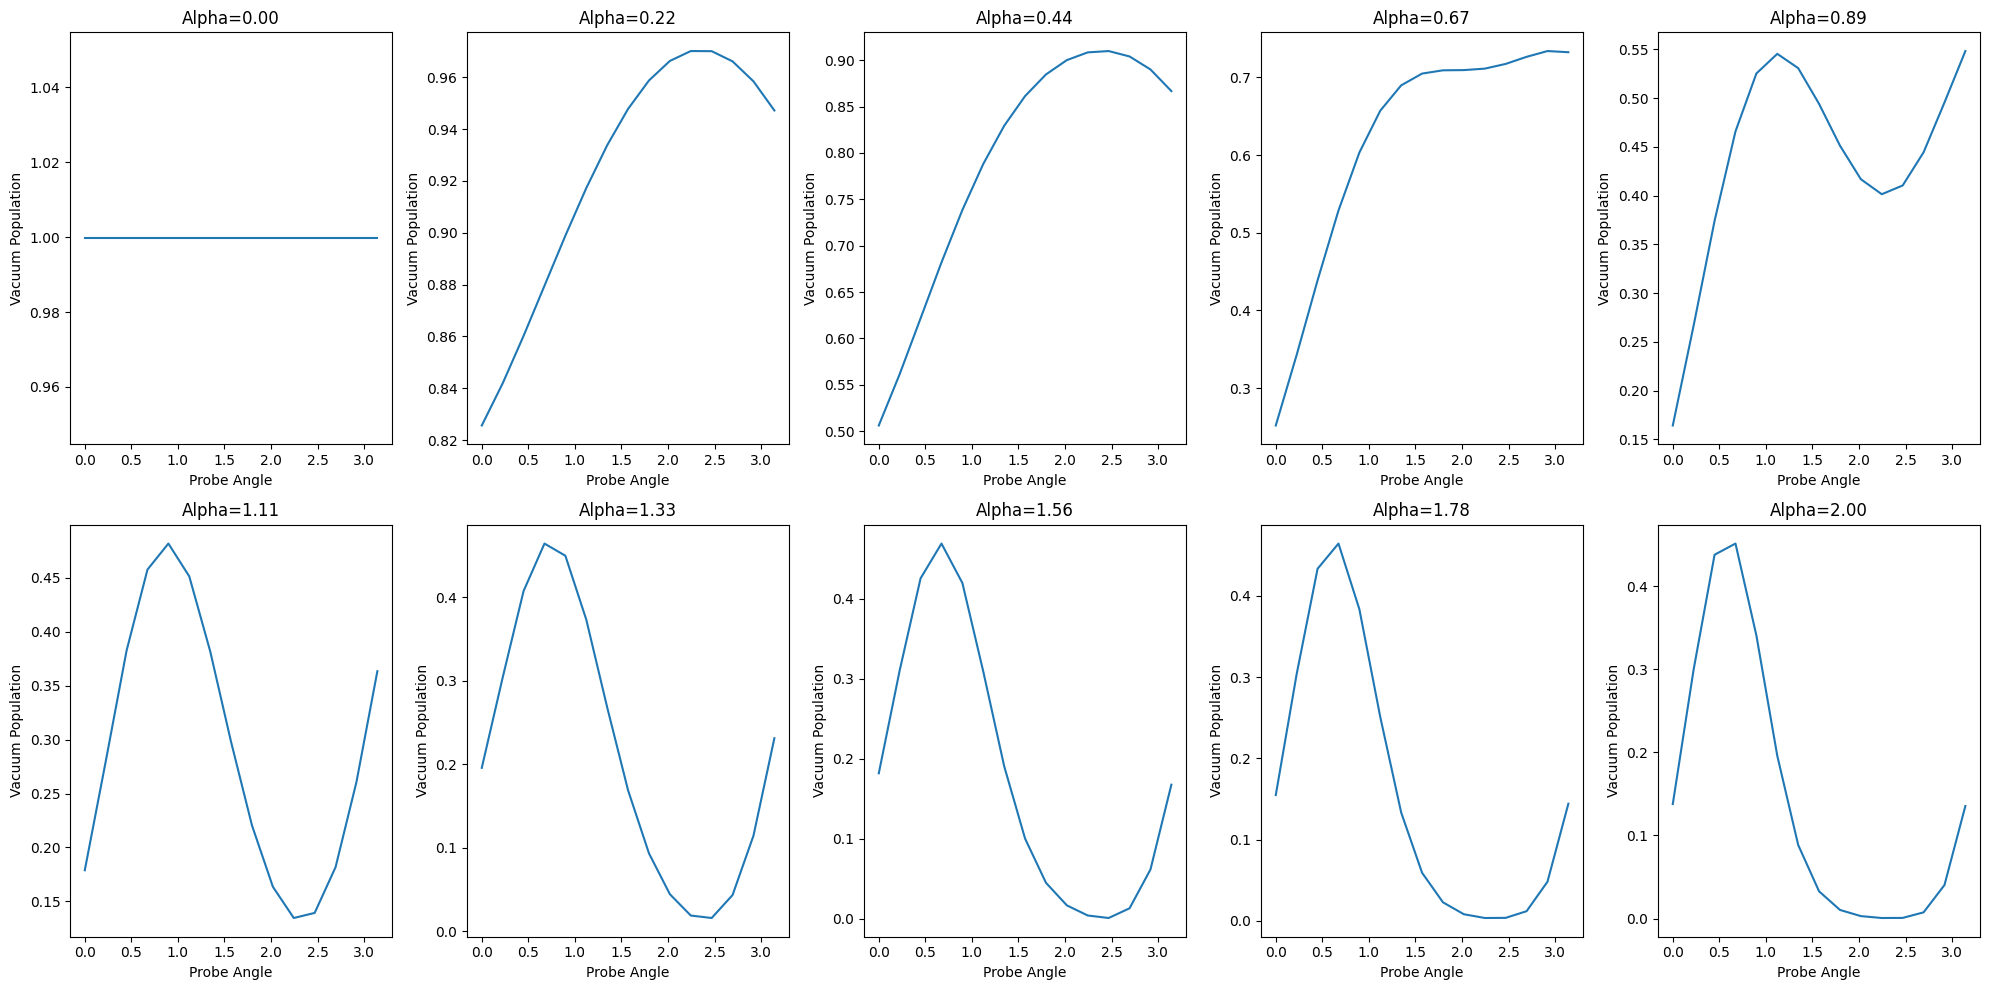

In [75]:
fig,ax = plt.subplots(2,5,figsize=(20,10))
for key,ax in zip(data.keys(),ax.flatten()):
    ax.plot(data[key]['probe_angles'],data[key]['vacuum_population'])
    ax.set_title(f'Alpha={float(key):.2f}')
    ax.set_xlabel('Probe Angle')
    ax.set_ylabel('Vacuum Population')
    
fig.tight_layout()
plt.show()



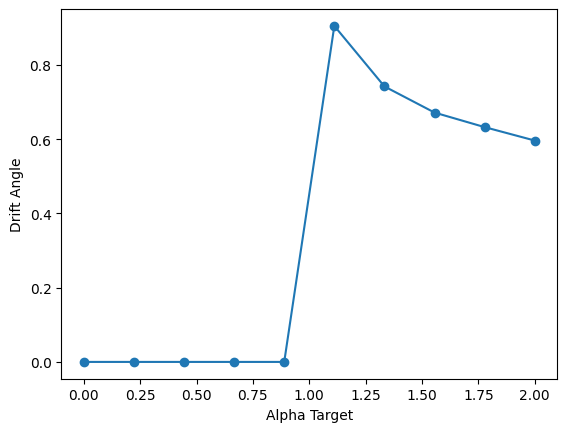

In [76]:
alpha = list(data.keys())

drift_angles = [data[alpha]["drift_angle"] for alpha in alpha]
alpha = [float(alpha) for alpha in alpha]
drift_angles = np.unwrap(drift_angles)
plt.plot(alpha, -drift_angles, '-o')
plt.xlabel("Alpha Target")
plt.ylabel("Drift Angle")
plt.show()

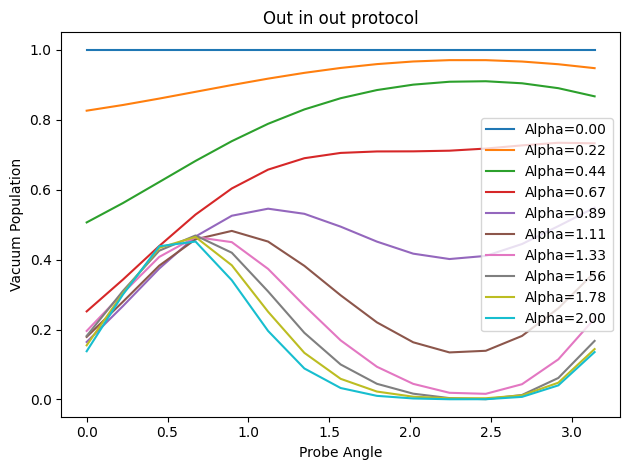

In [77]:

for key in data.keys():
    plt.plot(data[key]['probe_angles'],data[key]['vacuum_population'],label=f'Alpha={float(key):.2f}')
    plt.title(f'Out in out protocol')
    plt.xlabel('Probe Angle')
    plt.ylabel('Vacuum Population')
plt.legend()
plt.tight_layout()
plt.show()

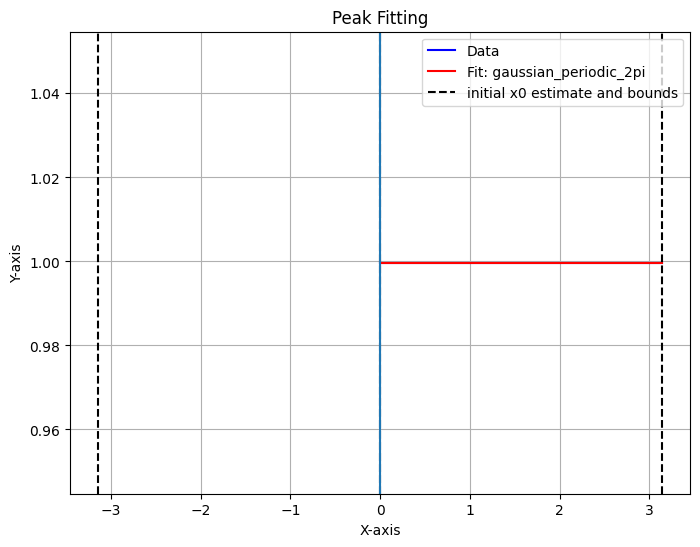

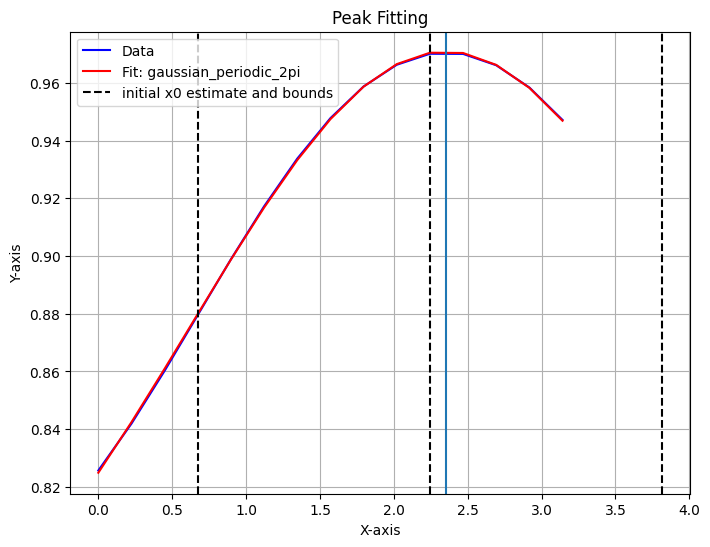

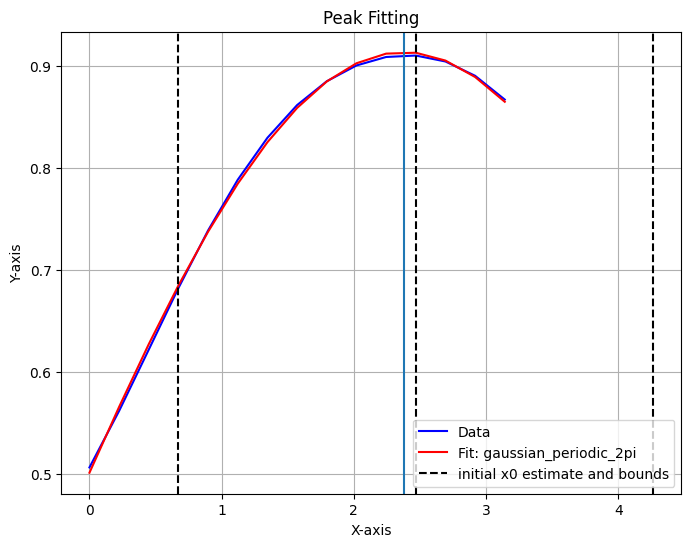

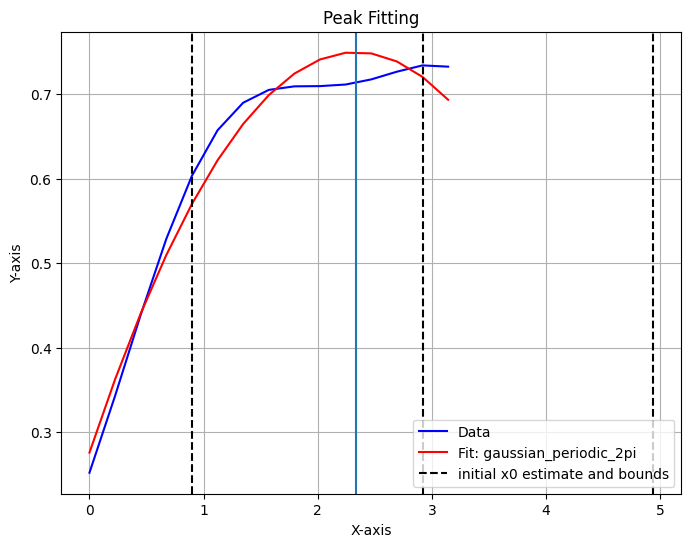

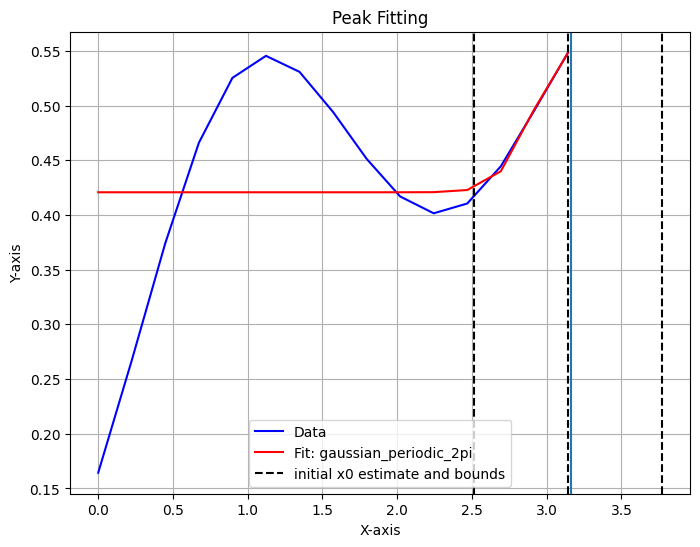

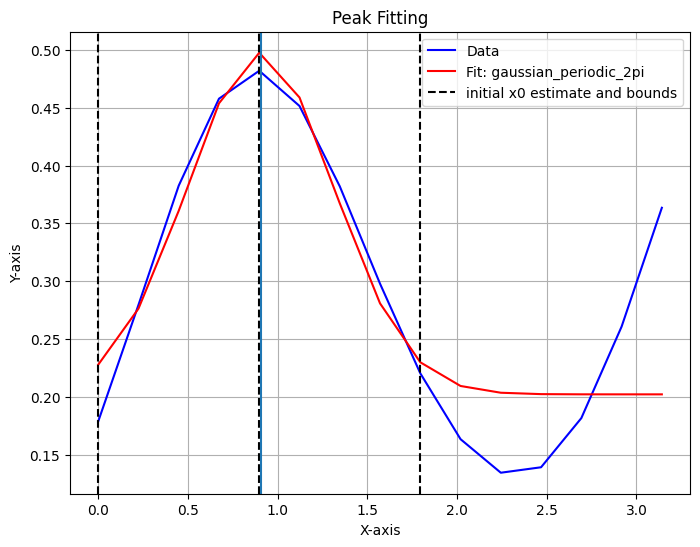

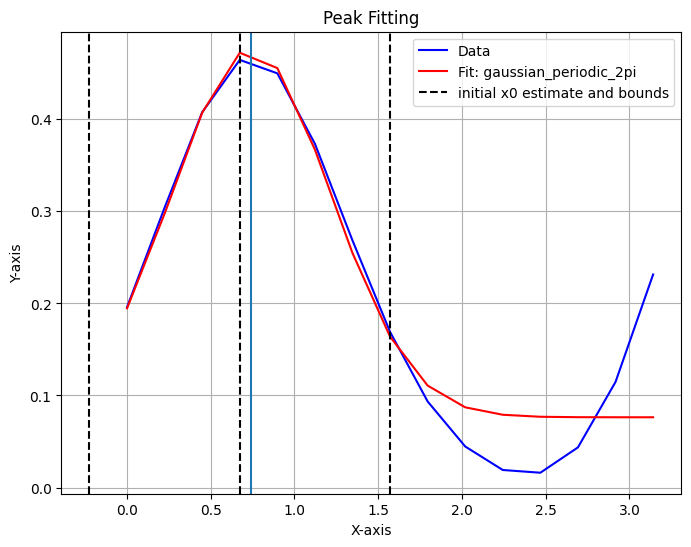

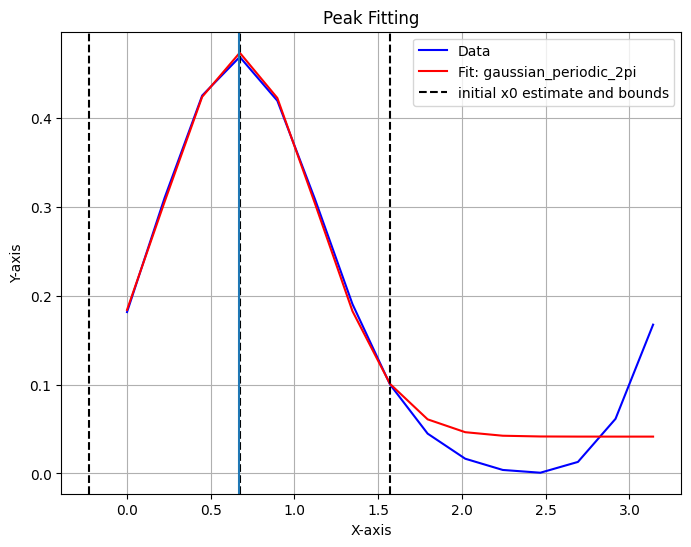

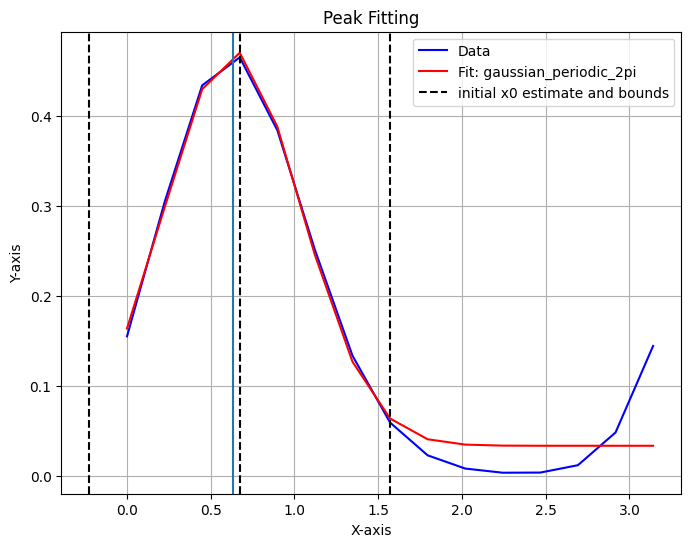

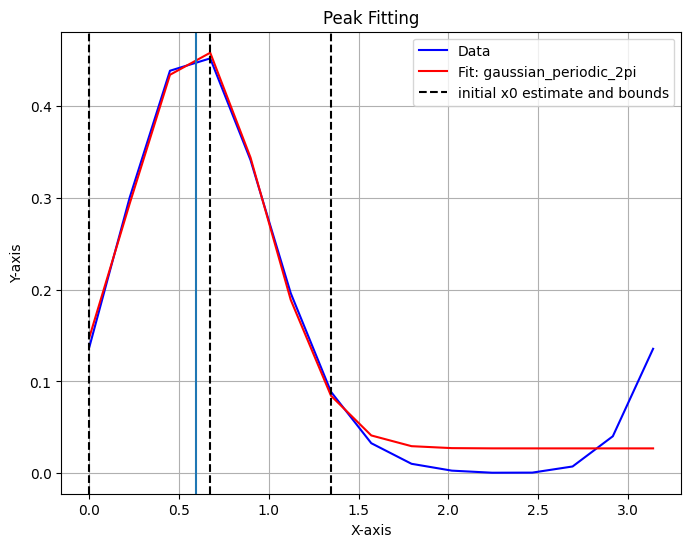

In [82]:
import sys
import os

# Use os.path.abspath with relative path as __file__ is not defined in Jupyter Notebooks
import os
import sys

# Define __file__ for Jupyter Notebook environment
__file__ = os.path.abspath('')
sys.path.append('D:\PhD_All_Code\quantum-pulse-simulator\quantum-pulse-simulator\examples\ATS')

from calibration_utils import disp_calib, disp_calib_plot, fit_peak
from basic_utils import gaussian_periodic_2pi

probe_angles = data[key]['probe_angles']
drift_angles = []
for key in data.keys()  :
    Vacuum_population = data[key]['vacuum_population']
    result = fit_peak(
                probe_angles,
                Vacuum_population,
                peak_found_threshold=5,
                peak_func=gaussian_periodic_2pi,
                peak_direction='up',
                plot=True
            )
    drift_angles.append(-result["popt"][0])



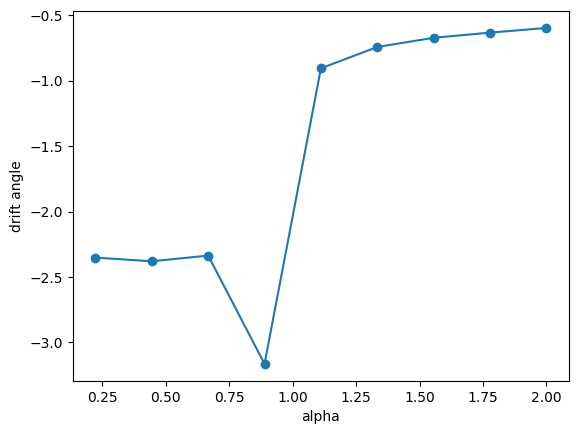

In [83]:
plt.plot(alpha[1:], drift_angles[1:], '-o')
plt.xlabel('alpha')
plt.ylabel('drift angle')
plt.show()
